In [5]:
import os

import pandas as pd
import numpy as np

from sklearn.manifold import TSNE

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib import cm
import matplotlib.patheffects as PathEffects

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


In [2]:
os.getcwd()

'/Users/yilingyun/Documents/WorkInProgress/Charade/latent-force-model-project/human/behavioralExpData/exp1'

## Data Cleaning for 1000+ videos

In [90]:
subj = pd.read_csv("./raw/subj_HSvideo_all.txt")
subj.head()

,num,date,startTime,id,userAgent,endTime,duration,quizAttemptN,instrReadingTimes,quickReadingPageN,...,hiddenDurations,comments,serious,maximized,problems,gender,age,inView,viewportW,viewportH
0,1005,2025-09-30,22:49:53,71973,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,23:14:10,24.270883,1,"{""0"":4.998,""1"":16.654,""2"":17.572,""3"":21.887,""4...",0,...,NaN,Nothing at this moment. Take care,1,1,The procedure was very straightforward,M,16,True,1470,919
1,1006,2025-09-30,22:54:04,70942,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,23:27:39,33.585817,1,"{""0"":2.131,""1"":3.647,""2"":5.097,""3"":24.914,""4"":...",0,...,NaN,NaN,1,1,i did not have any problems with completing th...,F,20,True,1440,900
2,1010,2025-09-30,23:22:35,66655,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,23:44:33,21.963450,1,"{""0"":2.577,""1"":4.598,""2"":7.353,""3"":11.141,""4"":...",0,...,NaN,No,1,1,No,F,20,True,1366,768
3,1008,2025-09-30,23:02:23,71066,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,23:46:42,44.310650,1,"{""0"":25.214,""1"":27.752,""2"":42.453,""3"":51.44,""4...",0,...,937.127,no,1,1,no,M,19,True,1707,1067
4,1013,2025-09-30,23:33:41,62755,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,23:49:37,15.925067,1,"{""0"":21.615,""1"":81.845,""2"":85.278,""3"":89.247,""...",0,...,NaN,NaN,1,1,NaN,F,21,True,1440,900


In [91]:
subj.columns

Index(['num', 'date', 'startTime', 'id', 'userAgent', 'endTime', 'duration',
       'quizAttemptN', 'instrReadingTimes', 'quickReadingPageN', 'hiddenCount',
       'hiddenDurations', 'comments', 'serious', 'maximized', 'problems',
       'gender', 'age', 'inView', 'viewportW', 'viewportH'],
      dtype='object')

In [92]:
len(subj)

782

In [93]:
sum(subj.serious == 0)

33

In [94]:
sum(subj.maximized == 0)

20

In [95]:
excludedSubjNum = pd.concat([subj.loc[subj.serious == 0, "num"], subj.loc[subj.maximized == 0, "num"]])
excludedSubjNum = list(excludedSubjNum)
excludedSubjNum

[1011,
 147,
 185,
 209,
 189,
 215,
 218,
 221,
 305,
 334,
 376,
 414,
 493,
 522,
 535,
 587,
 598,
 644,
 648,
 649,
 653,
 705,
 722,
 792,
 803,
 804,
 810,
 823,
 853,
 884,
 895,
 896,
 925,
 119,
 185,
 189,
 268,
 349,
 472,
 530,
 540,
 569,
 592,
 605,
 648,
 685,
 732,
 747,
 820,
 884,
 897,
 916,
 926]

In [96]:
cleanedSubj = subj[~subj.num.isin(excludedSubjNum)]
n = len(cleanedSubj.num)
n

733

In [97]:
trial = pd.read_csv("./raw/trial_HSvideo_all.txt")
trial.head()

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,label,labelIndex,rt,vidPlayCounts
0,1005,2025-09-30,22:49:53,0,5817_creep up on,Creep up on,9,9.628,1
1,1005,2025-09-30,22:49:53,1,5837_kiss,Flirt with,0,11.922,1
2,1005,2025-09-30,22:49:53,2,5840_avoid,Follow,5,69.310,3
3,1005,2025-09-30,22:49:53,3,5844_escape,Follow,5,26.870,1
4,1005,2025-09-30,22:49:53,4,5873_approach,Poke,16,6.797,1


In [19]:
trialN = 68
trial.shape[0]/trialN

784.0

In [21]:
# incomplete
incompleteSubjNum = trial.subjNum.value_counts().loc[lambda x : x < trialN].index
incompleteSubjNum

Index([], dtype='int64', name='subjNum')

In [22]:
completeTrial = trial[~trial.subjNum.isin(incompleteSubjNum)]
completeTrial.head()

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,label,labelIndex,rt,vidPlayCounts
0,1005,2025-09-30,22:49:53,0,5817_creep up on,Creep up on,9,9.628,1
1,1005,2025-09-30,22:49:53,1,5837_kiss,Flirt with,0,11.922,1
2,1005,2025-09-30,22:49:53,2,5840_avoid,Follow,5,69.310,3
3,1005,2025-09-30,22:49:53,3,5844_escape,Follow,5,26.870,1
4,1005,2025-09-30,22:49:53,4,5873_approach,Poke,16,6.797,1


In [23]:
#drop not serious or not maximized
excSubjTrial = completeTrial[~completeTrial.subjNum.isin(excludedSubjNum)]
excSubjTrial.head()

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,label,labelIndex,rt,vidPlayCounts
0,1005,2025-09-30,22:49:53,0,5817_creep up on,Creep up on,9,9.628,1
1,1005,2025-09-30,22:49:53,1,5837_kiss,Flirt with,0,11.922,1
2,1005,2025-09-30,22:49:53,2,5840_avoid,Follow,5,69.310,3
3,1005,2025-09-30,22:49:53,3,5844_escape,Follow,5,26.870,1
4,1005,2025-09-30,22:49:53,4,5873_approach,Poke,16,6.797,1


In [24]:
len(np.unique(excSubjTrial.subjNum))

735

In [25]:
missingTrial = list(set(np.unique(cleanedSubj.num)) - set(np.unique(excSubjTrial.subjNum))) # has subj data but not trial data
missingTrial

[618]

In [26]:
missingSubj = list(set(np.unique(excSubjTrial.subjNum)) - set(np.unique(cleanedSubj.num))) # has trial data but not subj data
missingSubj

[928, 713, 930]

In [29]:
cleanedSubj = cleanedSubj.loc[~cleanedSubj.num.isin(list(missingTrial)) & ~cleanedSubj.num.isin(list(missingSubj))] 

In [30]:
cleanedTrial = excSubjTrial.loc[~excSubjTrial.subjNum.isin(list(missingTrial)) & ~excSubjTrial.subjNum.isin(list(missingSubj))]

In [31]:
n = len(np.unique(cleanedTrial.subjNum))
cleanedSubj.to_csv(f"{n}subj_cleaned_subj_HSvideo.csv", sep = "\t")
cleanedTrial = cleanedTrial.reset_index(drop = True)
cleanedTrial.to_csv(f"./{n}subj_cleaned_trial_HSvideo.csv", sep = "\t", index = False, header = True)

# Data analysis

## subj

In [6]:
n = 732
cleanedSubj = pd.read_csv(f"./{n}subj_cleaned_subj_HSvideo.csv", sep = "\t")
cleanedSubj.head()

,Unnamed: 0,num,date,startTime,id,userAgent,endTime,duration,quizAttemptN,instrReadingTimes,...,hiddenDurations,comments,serious,maximized,problems,gender,age,inView,viewportW,viewportH
0,0,1005,2025-09-30,22:49:53,71973,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,23:14:10,24.270883,1,"{""0"":4.998,""1"":16.654,""2"":17.572,""3"":21.887,""4...",...,NaN,Nothing at this moment. Take care,1,1,The procedure was very straightforward,M,16,True,1470,919
1,1,1006,2025-09-30,22:54:04,70942,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,23:27:39,33.585817,1,"{""0"":2.131,""1"":3.647,""2"":5.097,""3"":24.914,""4"":...",...,NaN,NaN,1,1,i did not have any problems with completing th...,F,20,True,1440,900
2,2,1010,2025-09-30,23:22:35,66655,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,23:44:33,21.963450,1,"{""0"":2.577,""1"":4.598,""2"":7.353,""3"":11.141,""4"":...",...,NaN,No,1,1,No,F,20,True,1366,768
3,3,1008,2025-09-30,23:02:23,71066,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,23:46:42,44.310650,1,"{""0"":25.214,""1"":27.752,""2"":42.453,""3"":51.44,""4...",...,937.127,no,1,1,no,M,19,True,1707,1067
4,4,1013,2025-09-30,23:33:41,62755,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,23:49:37,15.925067,1,"{""0"":21.615,""1"":81.845,""2"":85.278,""3"":89.247,""...",...,NaN,NaN,1,1,NaN,F,21,True,1440,900


In [7]:
cleanedSubj.gender.value_counts()

gender
F    591
M    126
N      9
O      6
Name: count, dtype: int64

In [8]:
cleanedSubj.age.mean()

19.94535519125683

In [9]:
cleanedSubj.duration.median()

19.0675

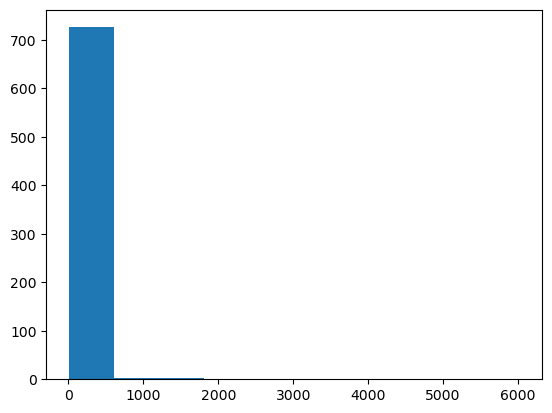

In [10]:
plt.hist(cleanedSubj.duration)
plt.show()

## trial

In [11]:
cleanedTrial = pd.read_csv(f"./{n}subj_cleaned_trial_HSvideo.csv", sep = "\t")
cleanedTrial.head()

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,label,labelIndex,rt,vidPlayCounts
0,1005,2025-09-30,22:49:53,0,5817_creep up on,Creep up on,9,9.628,1
1,1005,2025-09-30,22:49:53,1,5837_kiss,Flirt with,0,11.922,1
2,1005,2025-09-30,22:49:53,2,5840_avoid,Follow,5,69.310,3
3,1005,2025-09-30,22:49:53,3,5844_escape,Follow,5,26.870,1
4,1005,2025-09-30,22:49:53,4,5873_approach,Poke,16,6.797,1


In [12]:
subjN = len(np.unique(cleanedTrial.subjNum))
subjN

732

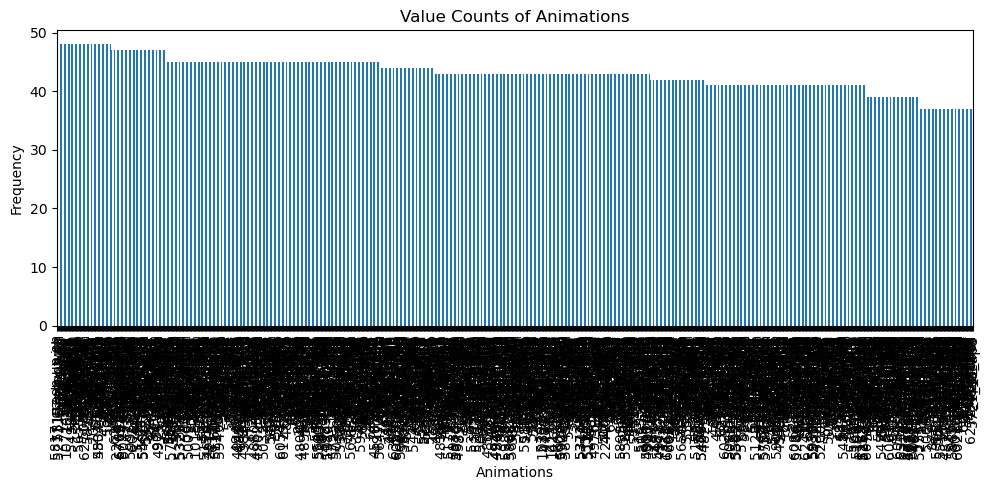

In [13]:
counts = cleanedTrial.exptId.value_counts()
counts.plot(kind='bar', figsize=(10, 5))
plt.title("Value Counts of Animations")
plt.xlabel("Animations")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [14]:
counts

exptId
5817_creep up on    48
5197_capture        48
5315_play with      48
5271_creep up on    48
5264_pull           48
                    ..
4807_herd           37
6272_approach       37
4841_mimic          37
4845_kiss           37
5721_escape         37
Name: count, Length: 1156, dtype: int64

In [15]:
# Plot relative frequency
counts = cleanedTrial.label.value_counts()
# Convert counts to relative frequency
rel_freq_human = counts / counts.sum()

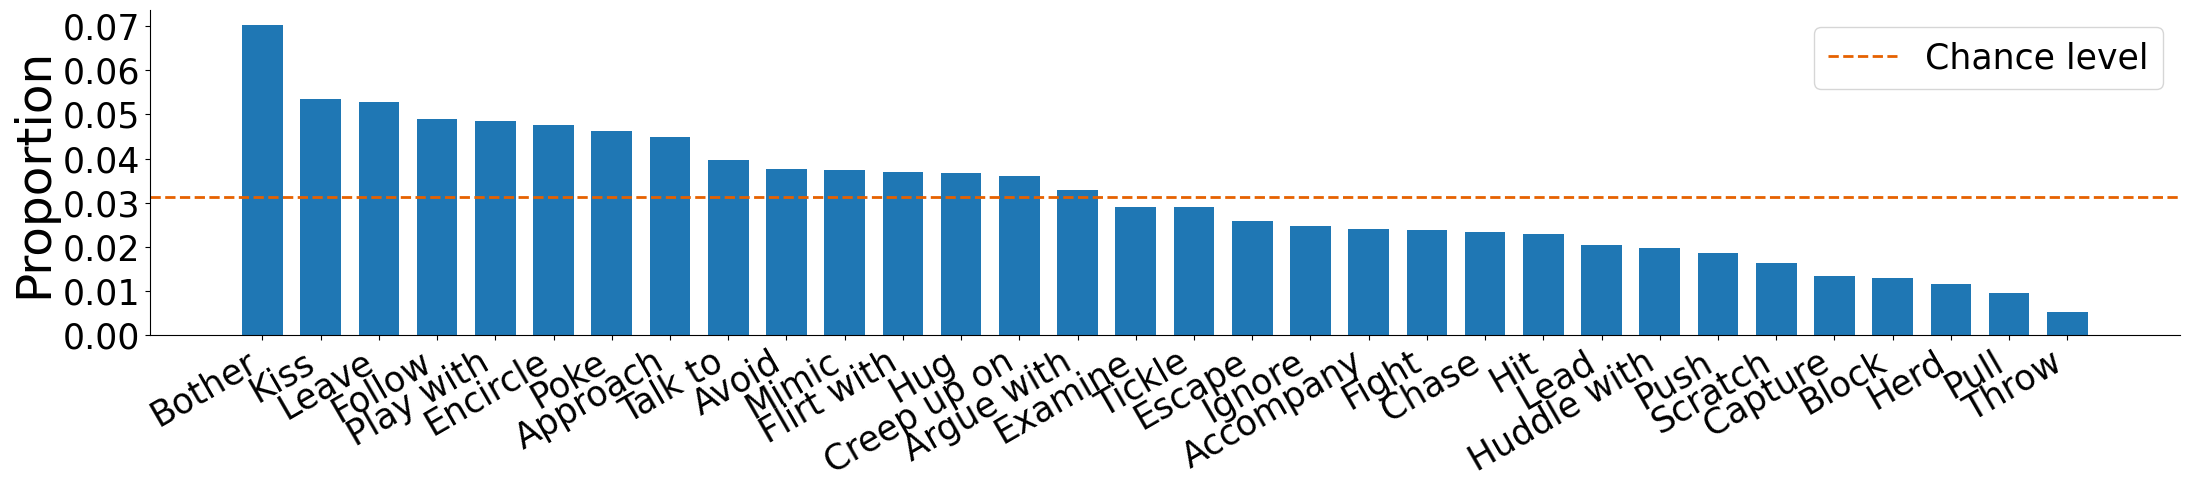

In [23]:
# Plot
labels = rel_freq_human.index.tolist()
values = rel_freq_human.values
x = np.arange(len(labels))  # explicit x positions

f, ax = plt.subplots(figsize=(22, 5))
plt.bar(x, values, width=0.7)

plt.xticks(x, labels, rotation=30, ha='right', fontsize=25)  
plt.yticks(fontsize=25)
plt.ylabel('Proportion', fontsize=35)
# title = "Relative Frequency of Human Selected Labels"
plt.axhline(1/len(labels), color='#E66100', linestyle='--', linewidth=2, label='Chance level')
plt.legend(fontsize=25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
f.savefig('study1_rel_freq.png', bbox_inches='tight', dpi = 300)

# Get response matrix

In [46]:
verbOrder = list(np.unique(cleanedTrial.label)) # alphabetic order
verbOrderLower = [v.lower() for v in verbOrder]
videos = list(np.unique(cleanedTrial.exptId))

In [47]:
orderedVideos = []
for verb in verbOrder:
    # find all videos that contain the verb (case-insensitive)
    matches = [v for v in videos if verb.lower() in v.lower()]
    orderedVideos.extend(matches)

## Create the response matrix

In [59]:
def get_confMat(row, cMat):
    video = row.exptId
    label = row.label
    cMat.loc[video, label] = cMat.loc[video, label] + 1
    return

In [60]:
responseMat = pd.DataFrame(0, columns = list(verbOrder), index = list(orderedVideos))

In [61]:
cleanedTrial.apply(lambda row: get_confMat(row, responseMat), axis = 1)

0        None
1        None
2        None
3        None
4        None
         ... 
49771    None
49772    None
49773    None
49774    None
49775    None
Length: 49776, dtype: object

In [62]:
counts = cleanedTrial.exptId.value_counts()
counts = counts.astype(float)  # for division
responseMat = responseMat.div(counts, axis=0)
responseMat

,Accompany,Approach,Argue with,Avoid,Block,Bother,Capture,Chase,Creep up on,Encircle,...,Leave,Mimic,Play with,Poke,Pull,Push,Scratch,Talk to,Throw,Tickle
1002_mimic,0.024390,0.000000,0.024390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.707317,0.073171,0.000000,0.000000,0.000000,0.000000,0.024390,0.0,0.000000
1003_scratch,0.000000,0.000000,0.000000,0.000000,0.000000,0.044444,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.022222,0.133333,0.000000,0.000000,0.288889,0.000000,0.0,0.177778
1007_chase,0.022727,0.000000,0.000000,0.045455,0.000000,0.022727,0.000000,0.204545,0.022727,0.0,...,0.0,0.022727,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1012_push,0.000000,0.000000,0.000000,0.000000,0.000000,0.042553,0.127660,0.106383,0.085106,0.0,...,0.0,0.021277,0.000000,0.234043,0.021277,0.085106,0.000000,0.000000,0.0,0.063830
1015_huddle with,0.044444,0.022222,0.000000,0.000000,0.022222,0.022222,0.022222,0.000000,0.000000,0.0,...,0.0,0.000000,0.022222,0.000000,0.000000,0.000000,0.000000,0.022222,0.0,0.022222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
952_follow,0.046512,0.000000,0.000000,0.046512,0.000000,0.023256,0.000000,0.116279,0.139535,0.0,...,0.0,0.000000,0.000000,0.000000,0.023256,0.000000,0.000000,0.000000,0.0,0.000000
990_poke,0.000000,0.044444,0.000000,0.000000,0.000000,0.088889,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.022222,0.355556,0.000000,0.000000,0.022222,0.000000,0.0,0.022222
991_kiss,0.023256,0.046512,0.023256,0.000000,0.000000,0.000000,0.023256,0.023256,0.069767,0.0,...,0.0,0.000000,0.046512,0.209302,0.046512,0.000000,0.000000,0.139535,0.0,0.023256
995_flirt with,0.000000,0.022727,0.295455,0.000000,0.022727,0.181818,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.045455,0.000000,0.000000,0.000000,0.000000,0.159091,0.0,0.022727


In [64]:
responseMat.to_csv(f"./{n}subj_response_distributions.csv", sep = "\t", index = True, header = True)

## Visualize response matrix

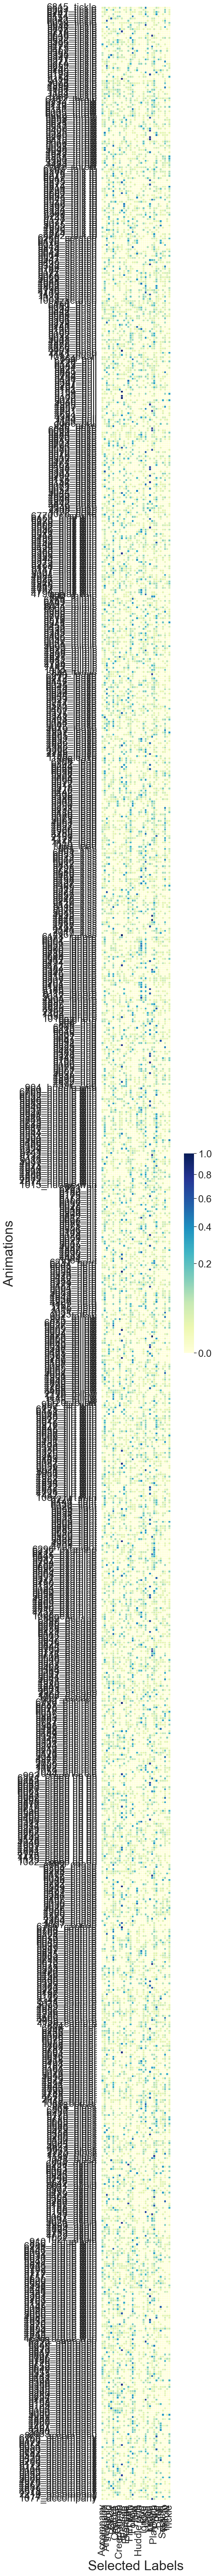

In [63]:
# Set up the matplotlib figure
title = "Measured human confusion matrix"
f, ax = plt.subplots(figsize=(11, 100))

# Generate a custom diverging colormap
cmap = sns.color_palette("YlGnBu", as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(responseMat, cmap=cmap, vmax=1, vmin=0, center=0.5, 
            # norm=LogNorm(vmin=1e-4, vmax=1), 
            norm=PowerNorm(gamma=0.5, vmin=0, vmax=1),
            xticklabels=verbOrder, yticklabels=orderedVideos,
            square=True, linewidths=0.5, cbar_kws={"shrink": .08})
sns.set(font_scale=2)
# sns.set_style("whitegrid", {'grid.linestyle': ''})
ax.set_xlabel("Selected Labels", fontsize=30)
ax.set_ylabel("Animations", fontsize=30)
ax.invert_yaxis()
# ax.set_title(title)
plt.show()
# f.savefig(title + '.png', bbox_inches='tight', dpi = 300)

## Reorder based on hierarchical clustering

In [71]:
responseMat = pd.read_csv("732subj_response_distributions.csv", sep = "\t", index_col=0)
responseMat

,Accompany,Approach,Argue with,Avoid,Block,Bother,Capture,Chase,Creep up on,Encircle,...,Leave,Mimic,Play with,Poke,Pull,Push,Scratch,Talk to,Throw,Tickle
1002_mimic,0.024390,0.000000,0.024390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.707317,0.073171,0.000000,0.000000,0.000000,0.000000,0.024390,0.0,0.000000
1003_scratch,0.000000,0.000000,0.000000,0.000000,0.000000,0.044444,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.022222,0.133333,0.000000,0.000000,0.288889,0.000000,0.0,0.177778
1007_chase,0.022727,0.000000,0.000000,0.045455,0.000000,0.022727,0.000000,0.204545,0.022727,0.0,...,0.0,0.022727,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1012_push,0.000000,0.000000,0.000000,0.000000,0.000000,0.042553,0.127660,0.106383,0.085106,0.0,...,0.0,0.021277,0.000000,0.234043,0.021277,0.085106,0.000000,0.000000,0.0,0.063830
1015_huddle with,0.044444,0.022222,0.000000,0.000000,0.022222,0.022222,0.022222,0.000000,0.000000,0.0,...,0.0,0.000000,0.022222,0.000000,0.000000,0.000000,0.000000,0.022222,0.0,0.022222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
952_follow,0.046512,0.000000,0.000000,0.046512,0.000000,0.023256,0.000000,0.116279,0.139535,0.0,...,0.0,0.000000,0.000000,0.000000,0.023256,0.000000,0.000000,0.000000,0.0,0.000000
990_poke,0.000000,0.044444,0.000000,0.000000,0.000000,0.088889,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.022222,0.355556,0.000000,0.000000,0.022222,0.000000,0.0,0.022222
991_kiss,0.023256,0.046512,0.023256,0.000000,0.000000,0.000000,0.023256,0.023256,0.069767,0.0,...,0.0,0.000000,0.046512,0.209302,0.046512,0.000000,0.000000,0.139535,0.0,0.023256
995_flirt with,0.000000,0.022727,0.295455,0.000000,0.022727,0.181818,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.045455,0.000000,0.000000,0.000000,0.000000,0.159091,0.0,0.022727


In [72]:
# 1️⃣ Extract the label (text after underscore)
response = responseMat.copy()
response["label"] = response.index.str.split("_").str[1]

# 2️⃣ Group by that label and take mean across all numeric columns
response_avg = response.groupby("label").mean(numeric_only=True).reindex(verbOrderLower)

# 3️⃣ (Optional) Drop the temporary label column from original
response_avg.head()

,Accompany,Approach,Argue with,Avoid,Block,Bother,Capture,Chase,Creep up on,Encircle,...,Leave,Mimic,Play with,Poke,Pull,Push,Scratch,Talk to,Throw,Tickle
label,,,,,,,,,,,,,,,,,,,,,
accompany,0.108790,0.045162,0.011349,0.019057,0.028807,0.032890,0.008420,0.030694,0.034911,0.009609,...,0.014076,0.070992,0.045560,0.040781,0.021024,0.014969,0.010273,0.030254,0.006234,0.019138
approach,0.026119,0.194156,0.009249,0.019810,0.006649,0.055466,0.006818,0.008989,0.102889,0.030635,...,0.006773,0.008321,0.034297,0.069250,0.011004,0.008107,0.015929,0.049058,0.002620,0.028107
argue with,0.008165,0.030094,0.265740,0.016003,0.002093,0.068111,0.001505,0.003697,0.008871,0.003625,...,0.013192,0.066643,0.070823,0.027760,0.004621,0.001581,0.008182,0.173081,0.001496,0.021010
avoid,0.017338,0.008317,0.019675,0.161604,0.004525,0.043683,0.004303,0.085618,0.015892,0.021864,...,0.172738,0.017230,0.057598,0.003670,0.009696,0.001830,0.002553,0.008631,0.006049,0.002901
block,0.026010,0.041451,0.012185,0.022917,0.170267,0.055192,0.029063,0.024135,0.022915,0.053822,...,0.008966,0.025995,0.054533,0.038047,0.006142,0.015745,0.009611,0.020510,0.001789,0.009680


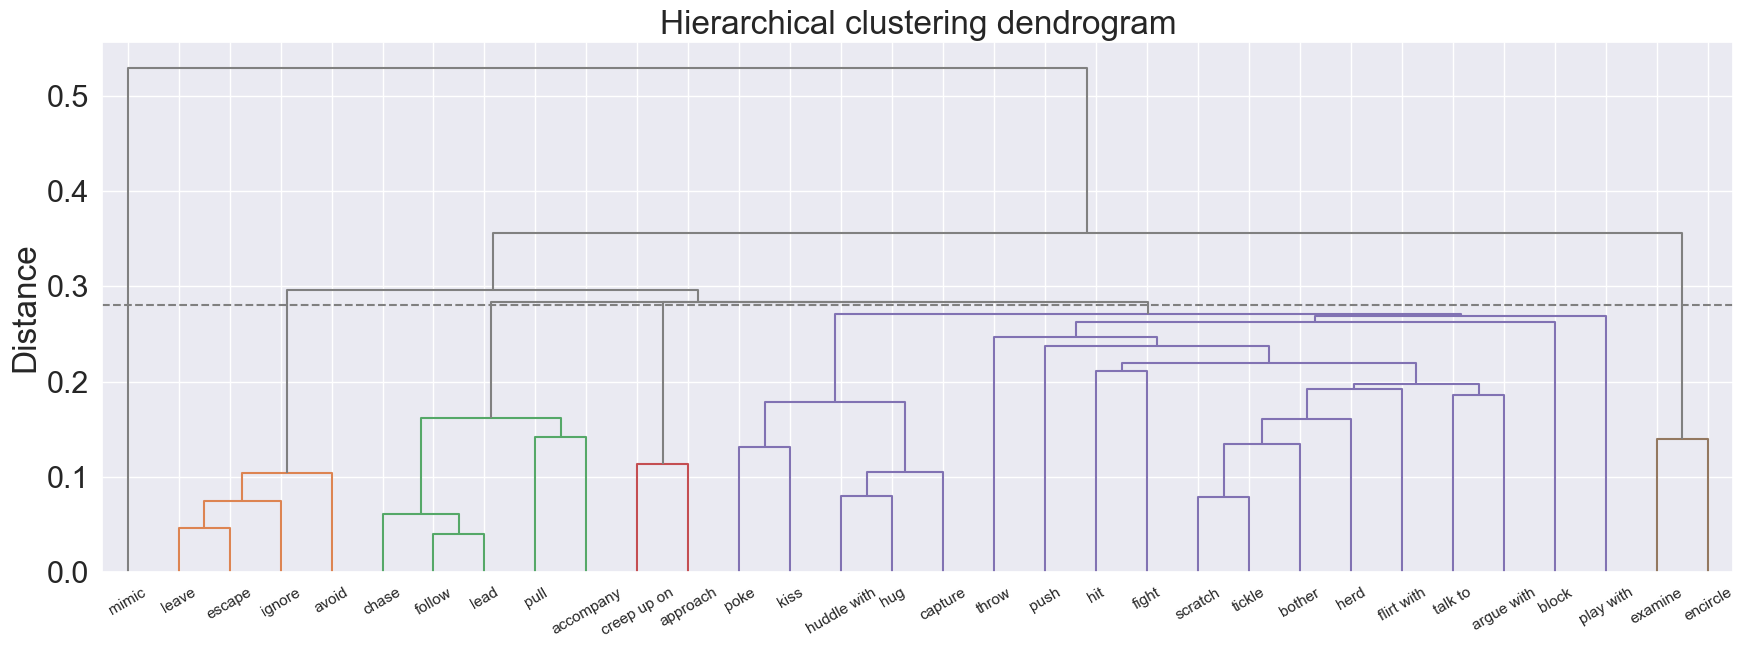

In [73]:
# 1) Choose a distance + linkage method
metric = "cosine" 
method = "single" 

# SciPy linkage can take X directly for many cases, but pdist makes it explicit:
D = pdist(response_avg, metric=metric)          # condensed distance vector
Z = linkage(D, method=method, optimal_ordering=True)        # hierarchical clustering

# 2) Pick a cut height (the dashed line)
cut_height = 0.28 

# 3) Plot dendrogram
fig, ax = plt.subplots(figsize=(18, 7))
d = dendrogram(
    Z,
    labels=response_avg.index,
    leaf_rotation=30,     # rotate x labels like your figure
    leaf_font_size=11,
    color_threshold=cut_height,  # colors branches below this height
    above_threshold_color="0.5"  # gray above threshold
)
ordered_labels_hc = d["ivl"]

ax.axhline(cut_height, ls="--", lw=1.5, color="0.5")
ax.set_ylabel("Distance")
ax.set_title("Hierarchical clustering dendrogram")
plt.tight_layout()
plt.show()

In [74]:
ordered_labels_hc

['mimic',
 'leave',
 'escape',
 'ignore',
 'avoid',
 'chase',
 'follow',
 'lead',
 'pull',
 'accompany',
 'creep up on',
 'approach',
 'poke',
 'kiss',
 'huddle with',
 'hug',
 'capture',
 'throw',
 'push',
 'hit',
 'fight',
 'scratch',
 'tickle',
 'bother',
 'herd',
 'flirt with',
 'talk to',
 'argue with',
 'block',
 'play with',
 'examine',
 'encircle']

# Plot TSNE

In [78]:
response_avg.columns = [w.lower() for w in response_avg.columns]
response_avg_reordered = response_avg.loc[ordered_labels_hc, ordered_labels_hc]
response_avg_reordered

,mimic,leave,escape,ignore,avoid,chase,follow,lead,pull,accompany,...,tickle,bother,herd,flirt with,talk to,argue with,block,play with,examine,encircle
label,,,,,,,,,,,,,,,,,,,,,
mimic,0.513729,0.015050,0.005731,0.014824,0.027050,0.007645,0.041963,0.022924,0.004467,0.028666,...,0.001279,0.014755,0.003217,0.029222,0.056069,0.028337,0.006309,0.067257,0.010041,0.009915
leave,0.001693,0.536084,0.140287,0.049437,0.146181,0.003966,0.002394,0.015040,0.010377,0.002909,...,0.001718,0.009013,0.004052,0.001712,0.004101,0.004750,0.002302,0.006471,0.006875,0.003385
escape,0.008714,0.324128,0.151098,0.037651,0.132040,0.065053,0.052517,0.020797,0.006543,0.004981,...,0.005739,0.038833,0.011027,0.004179,0.006023,0.017622,0.004395,0.021729,0.009128,0.007419
ignore,0.009736,0.238368,0.080326,0.081653,0.131738,0.014379,0.015469,0.012384,0.011985,0.013538,...,0.009310,0.097458,0.007124,0.016583,0.028549,0.053101,0.004867,0.029154,0.024910,0.009869
avoid,0.017230,0.172738,0.096740,0.038618,0.161604,0.085618,0.114900,0.033618,0.009696,0.017338,...,0.002901,0.043683,0.011205,0.004822,0.008631,0.019675,0.004525,0.057598,0.017758,0.021864
chase,0.058242,0.006339,0.033090,0.011754,0.055654,0.154875,0.212668,0.057100,0.014904,0.048970,...,0.009270,0.039857,0.020433,0.016494,0.007773,0.014870,0.013924,0.074284,0.009130,0.006235
follow,0.071015,0.008777,0.011362,0.015344,0.063907,0.097256,0.296218,0.082413,0.017235,0.051339,...,0.005271,0.037129,0.022801,0.017561,0.022359,0.009527,0.011720,0.028668,0.006738,0.006063
lead,0.039847,0.022993,0.014308,0.022072,0.048425,0.065216,0.232564,0.123022,0.021464,0.077135,...,0.007419,0.032280,0.023188,0.026889,0.011644,0.010775,0.007902,0.048763,0.010954,0.016796
pull,0.011346,0.011102,0.009750,0.011216,0.031799,0.028023,0.125875,0.074124,0.052681,0.082478,...,0.018435,0.046047,0.018472,0.059303,0.018748,0.013285,0.005279,0.054836,0.009537,0.006613


In [79]:
# --- Step 1: Extract verb labels from "video_action" strings like "1234_lead"
labels = responseMat.index
labelTxt = [lbl.split('_')[1] for lbl in labels]
labelTxt = np.array(labelTxt)

In [80]:
# --- Step 2: Run t-SNE with standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(responseMat)

tsne = TSNE(n_components=2, perplexity=20, learning_rate=400,
            early_exaggeration=20, init='random', method='barnes_hut',
            random_state=42)
XY = tsne.fit_transform(X_scaled)

In [81]:
# --- Step 3: Map each verb to a color based on its index in catNames
# from matplotlib.cm import get_cmap
labelTxt_lower = [l.lower() for l in labelTxt]
idx_reorder = np.array([ordered_labels_hc.index(l) for l in labelTxt_lower])
nCats = len(verbOrderLower)

cmap = cm.get_cmap('turbo', nCats)  # perceptual colormap
pointColors = np.array([cmap(i) for i in idx_reorder])

/var/folders/k7/mm5crvhx3210xfdblpr8gzsw0000gn/T/ipykernel_68469/3723912704.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo', nCats)  # perceptual colormap


In [82]:
# --- Step 4: Identify a representative (centroid) label per category
idxLabel = np.zeros(len(labelTxt), dtype=bool)

for cat in verbOrderLower:
    idx = np.where(np.array(labelTxt_lower) == cat)[0]
    if len(idx) == 0:
        continue
    center = XY[idx].mean(axis=0)
    dists = np.sum((XY[idx] - center) ** 2, axis=1)
    closest = idx[np.argmin(dists)]
    idxLabel[closest] = True

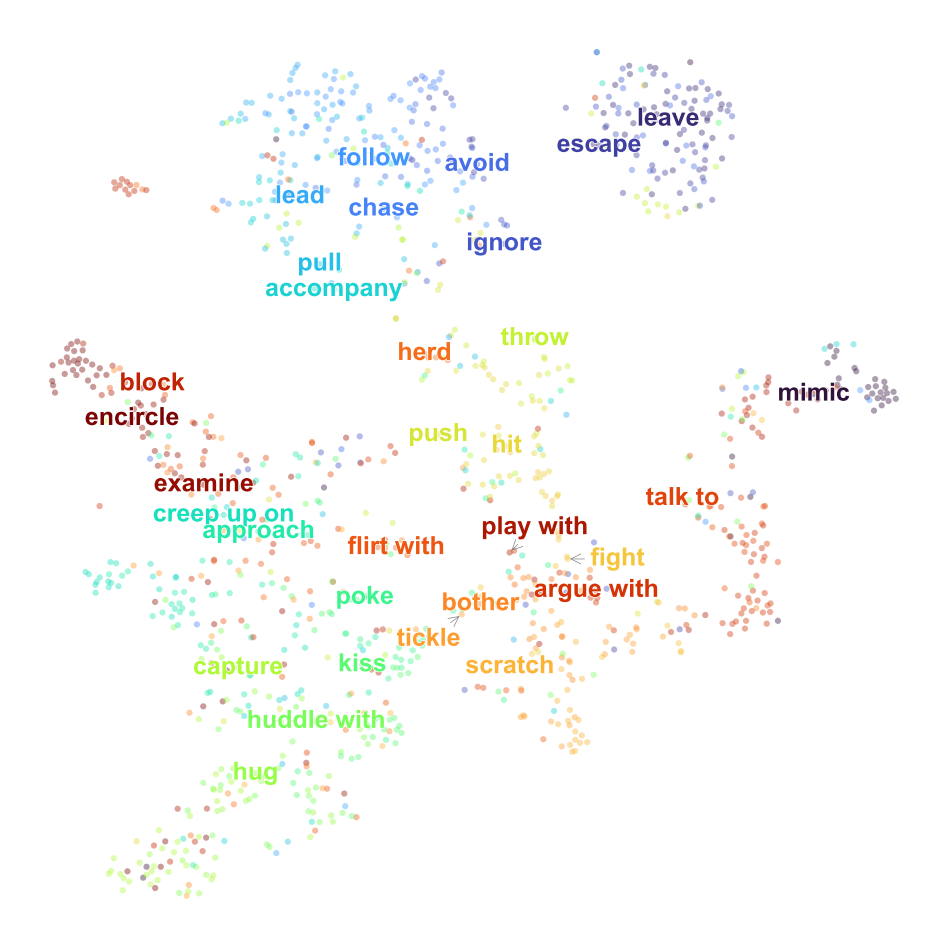

In [83]:
# --- Step 5: Plotting
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('white')  # set axes bg explicitly

# Plot points
ax.scatter(XY[:, 0], XY[:, 1], c=pointColors, s=20, alpha=0.4, edgecolors='none')

# Plot centroid-labeled points
for i, label in enumerate(labelTxt):
    if idxLabel[i]:
        
        if label == "tickle":
            dx = -4
            dy = -3
            txt = ax.annotate(label, (XY[i, 0], XY[i, 1]), xytext=(XY[i, 0]+dx, XY[i, 1]+dy), fontsize=18, fontweight='bold', 
                 color=pointColors[i], alpha=1, 
                 ha='center', va='center', arrowprops=dict(arrowstyle='->', color='grey', linewidth=0.5))
        elif label == "fight":
            dx = 6
            dy = 0
            txt = ax.annotate(label, (XY[i, 0], XY[i, 1]), xytext=(XY[i, 0]+dx, XY[i, 1]+dy), fontsize=18, fontweight='bold', 
                 color=pointColors[i], alpha=1, 
                 ha='center', va='center', arrowprops=dict(arrowstyle='->', color='grey', linewidth=0.5))
        elif label == "play with":
            dx = 3
            dy = 3
            txt = ax.annotate(label, (XY[i, 0], XY[i, 1]), xytext=(XY[i, 0]+dx, XY[i, 1]+dy), fontsize=18, fontweight='bold', 
                 color=pointColors[i], alpha=1, 
                 ha='center', va='center', arrowprops=dict(arrowstyle='->', color='grey', linewidth=0.5))
        else:
            txt = ax.text(XY[i, 0], XY[i, 1], label,
                 fontsize=18, fontweight='bold', 
                 color=pointColors[i], alpha=1, 
                 ha='center', va='center')
        txt.set_path_effects([PathEffects.Stroke(linewidth=1, foreground='white'), PathEffects.Normal()])

        
# --- Step 6: Add colorbar
# sm = plt.cm.ScalarMappable(cmap=ListedColormap(cmap), norm=plt.Normalize(vmin=0.5, vmax=nCats + 0.5))
# cb = plt.colorbar(sm, ax=ax, ticks=np.arange(1, nCats + 1))
# cb.ax.set_yticklabels(verbOrderLower)
# cb.set_label("Action Labels")

# plt.title("t-SNE of Human Response Matrix\nColored by Verb Label")
ax.set_aspect('auto')
ax.axis('off')
plt.tight_layout()
fig.savefig('study1_tsne.png', bbox_inches='tight', dpi = 300)
plt.show()

/var/folders/k7/mm5crvhx3210xfdblpr8gzsw0000gn/T/ipykernel_68469/538769617.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  clabelmap = cm.get_cmap('turbo', nCats).colors


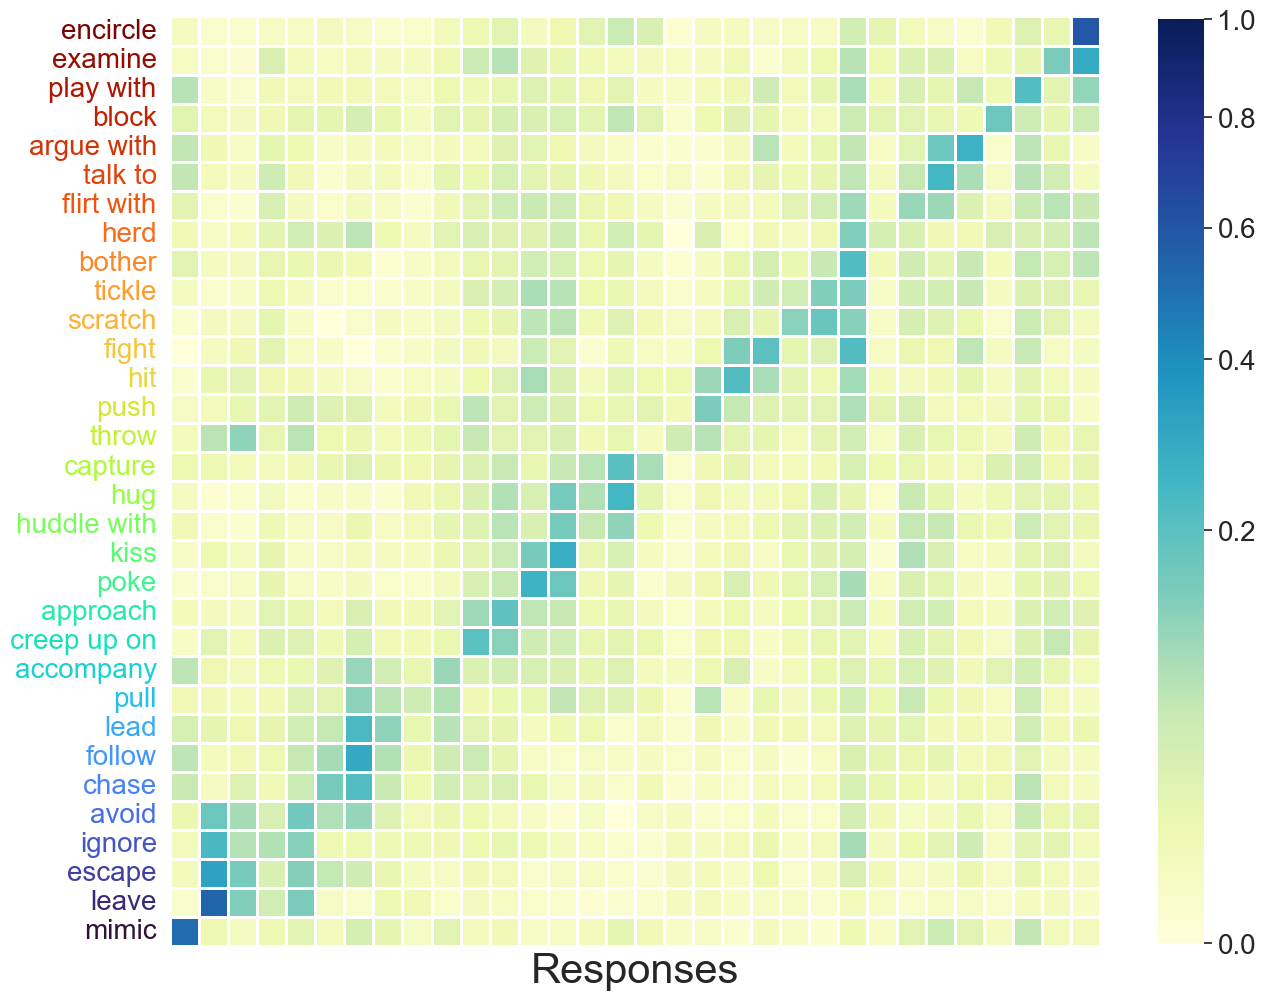

In [84]:
# Set up the matplotlib figure
# subjN = 732
# title = "Measured human response matrix"
f, ax = plt.subplots(figsize=(15, 15))

# Generate a custom diverging colormap
cmap = sns.color_palette("YlGnBu", as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
hm = sns.heatmap(response_avg_reordered, cmap=cmap, vmax=1, vmin=0, center=0.5, 
            # norm=LogNorm(vmin=1e-4, vmax=1), 
            norm=PowerNorm(gamma=0.5, vmin=0, vmax=1),
            xticklabels=response_avg_reordered.columns, yticklabels=response_avg_reordered.index,
            square=True, linewidths=1, cbar_kws={"shrink": .8})
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
ax.set_xlabel("Responses", fontsize=30)
# ax.set_ylabel("Animations", fontsize=30)
ax.set_ylabel("", fontsize=30)
plt.xticks([])

clabelmap = cm.get_cmap('turbo', nCats).colors
# Apply matching color to each label
for tick, color in zip(ax.get_yticklabels(), clabelmap):
    tick.set_color(color)
    # tick.set_fontweight(500)  # Optional for visibility
plt.tick_params(axis="both", labelsize=20)
ax.invert_yaxis()
# ax.set_title(title)
f.savefig('study1_response_matrix.png', bbox_inches='tight', dpi = 300)
plt.show()

# Get one-hot

In [85]:
# 1️⃣ Extract the label (the part after the underscore)
df = responseMat.copy()
df["label"] = df.index.str.split("_").str[1].str.lower()  # lowercase to match col names if needed

# 2️⃣ Create a one-hot version
onehot = pd.DataFrame(0, index=df.index, columns=df.columns)  # same shape, all zeros

# 3️⃣ Set the corresponding cell in each row to 1
for i, row in df.iterrows():
    label = row["label"].capitalize() if row["label"].capitalize() in onehot.columns else row["label"]
    if label in onehot.columns:
        onehot.at[i, label] = 1

# 4️⃣ Drop the extra column if needed
onehot = onehot.drop(columns=['label'])

In [86]:
onehot

,Accompany,Approach,Argue with,Avoid,Block,Bother,Capture,Chase,Creep up on,Encircle,...,Leave,Mimic,Play with,Poke,Pull,Push,Scratch,Talk to,Throw,Tickle
1002_mimic,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1003_scratch,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1007_chase,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1012_push,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1015_huddle with,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
952_follow,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
990_poke,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
991_kiss,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
995_flirt with,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [87]:
# Sum along columns (per row)
row_sums = onehot.sum(axis=1)

# Rows that violate one-hot (not exactly 1)
invalid_rows = onehot[row_sums != 1]

if len(invalid_rows) == 0:
    print("✅ Every row has exactly one value of 1.")
else:
    print(f"⚠️ {len(invalid_rows)} rows have incorrect one-hot encoding.")
    display(invalid_rows.head())

✅ Every row has exactly one value of 1.


In [92]:
# Extract true labels from index
true_labels = onehot.index.str.split("_").str[1].str.lower()

# Convert column names to lowercase for easy comparison
cols_lower = [c.lower() for c in onehot.columns]

# Find the column where each row has a 1
predicted_labels = onehot.idxmax(axis=1).str.lower()

# Compare
correct_rows = true_labels == predicted_labels
accuracy = correct_rows.mean()

print(f"✅ {accuracy*100:.2f}% of rows have the 1 in the correct column.")

# Show mismatches if any
mismatches = onehot.loc[~correct_rows]
if not mismatches.empty:
    print("⚠️ Mismatch examples:")
    display(mismatches.head())


✅ 100.00% of rows have the 1 in the correct column.


In [89]:
onehot.to_csv(f"./one_hot.csv", sep = "\t", index = True, header = True)